In [183]:
import pandas as pd
from PIL import Image
import numpy as np
import json
import torchvision
import torch
from os import path
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms.functional as F

device = "mps"

In [2]:
# Load movie metadata 
with open("../data/movie_info.json", "r") as f:
    data = json.load(f)

# Get cleaned poster names that map to the images saved with matching names
cleaned_poster_names = [name.split("/")[4] + ".jpg" for name in data.keys()]

### Prepare data

In [54]:
# Load images and map PIL.Image object to the movie name
not_found_poster_count = 0
loaded_images = {}
for poster_name in cleaned_poster_names:
    try:
        img_path = path.join("../data/posters/", poster_name)
        img = Image.open(img_path)
        loaded_images[poster_name] = img
    except FileNotFoundError as e:
        not_found_poster_count += 1

In [55]:
# Get all unique genres
genre_set = set()
for value in data.values():
    spec_genres = value.get("genre", None)
    if spec_genres:
        for genre in spec_genres:
            genre_set.add(genre)

# Map each genre to a row to use in multi-hot encodings
genre_mapping = {genre:idx for idx, genre in enumerate(genre_set)}

In [141]:
# Create mappings of posters to multi-hot encoded labels (genres)
# Does not include movies with no genres
poster_labels = {}
for key, value in data.items():
    spec_genres = value.get("genre", None)
    multi_hot_blueprint = np.zeros(19, dtype=np.float32)
    if spec_genres:
        for genre in spec_genres:
            multi_hot_blueprint[genre_mapping[genre]] = 1
        poster_labels[key.split("/")[4] + ".jpg"] = torch.from_numpy(multi_hot_blueprint)

In [142]:
poster_labels.get("my-revolution.jpg")

tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1.])

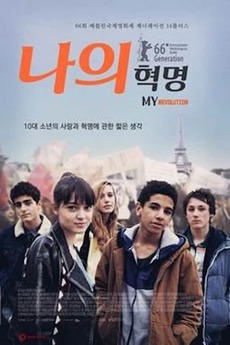

In [143]:
loaded_images.get("my-revolution.jpg")

In [144]:
common_movies = [movie for movie in poster_labels.keys() if movie in loaded_images.keys()]
print(len(common_movies))
print(len(poster_labels.keys()))

124847
126172


#### Custom Dataset and Data Loader

In [145]:
transformer = torchvision.models.VGG16_Weights.DEFAULT.transforms()

In [146]:
class PosterDataset(Dataset):
    def __init__(self, poster_labels, loaded_images):
        self.x = loaded_images
        self.y = poster_labels

        self.common_movies = [movie for movie in poster_labels.keys() if movie in loaded_images.keys()]
        
        # TODO: Probably there is a lot more efficient way to do this but who cares
        self.x = {movie:loaded_images.get(movie) for movie in self.common_movies}
        self.y = {movie:poster_labels.get(movie) for movie in self.common_movies}

        # Init the transformer
        self.transformer = torchvision.models.VGG16_Weights.DEFAULT.transforms() # Accepts batched PIL.Image (B, C, H, W) or single Tensor (C, H, W)

    def __getitem__(self, index):
        # Returns (PIL.Image, Multi-Hot Encoding)
        movie_name = self.common_movies[index]

        movie_poster = self.x[movie_name]
        movie_poster = movie_poster.convert("RGB") 
        movie_tensor = self.transformer(movie_poster)

        return movie_tensor, self.y.get(movie_name)

    def __len__(self):
        return len(self.common_movies)

In [147]:
torchvision.models.VGG16_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
dataset = PosterDataset(poster_labels=poster_labels, loaded_images=loaded_images)

In [199]:
# Split dataset into train and validation
generator = torch.Generator().manual_seed(42) # Handles the remainders from the split, used for reproducability
small_dataset, _ = random_split(dataset, (0.2, 0.8), generator=generator)
train_dataset, val_dataset, test_dataset = random_split(small_dataset, (0.8, 0.1, 0.1), generator=generator)

In [200]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)

In [231]:
# Load the VGG model with pretrained weights
model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)

In [ ]:
# Freeze feature extraction layers
for param in model.features.parameters():
    param.requires_grad = False

In [233]:
# We need to change the classifier. Lets try changinng the 6'th layer in the classifier to predict 19 genres. (4096 x 19)
model.classifier[6] = nn.Linear(in_features=4096, out_features=len(genre_set))

In [234]:
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [235]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [237]:
for epoch in range(5):

    # Training
    model.train()
    train_loss = 0.0
    for i, (images, targets) in enumerate(train_dataloader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(images)    
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        # if i % 100 == 0:
        #     print(f"Epoch {epoch} | Batch {i} | Loss {loss.item():.4f}")


    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i, (images, targets) in enumerate(val_dataloader):
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)    
            loss = criterion(logits, targets)

            val_loss += loss.item()
            
            # if i % 100 == 0:
            #     print(f"Epoch {epoch} | Batch {i} | Loss {loss.item():.4f}")

    print(f"Epoch {epoch}: train_loss={train_loss / len(train_dataloader):.4f}, val_loss={val_loss / len(val_dataloader):.4f}")


Epoch 0: train_loss=0.0671, val_loss=0.3161
Epoch 1: train_loss=0.0387, val_loss=0.3796


KeyboardInterrupt: 

In [219]:
model.eval()

with torch.no_grad():
    img = transformer(loaded_images.get("four-for-none.jpg")).unsqueeze(0).to(device)  # add batch dim
    logits = model(img)
    probs = torch.sigmoid(logits)[0]
    preds = (probs > 0.3).int()